In [1]:
%load_ext autoreload
%autoreload 2
%env ANYWIDGET_HMR=1

import matplotlib.pyplot as plt
import mudata
import celldega as dega
import numpy as np
import scanpy as sc
import pandas as pd
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point, Polygon
from skimage.io import imread, imsave
from celldega.pre.boundary_tile import batch_transform_geometries
from celldega.pre import _to_geometry
import warnings
warnings.filterwarnings("ignore")



env: ANYWIDGET_HMR=1


In [2]:
# dataset_name = 'Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_outs'
dataset_name = 'Xenium_V1_human_Pancreas_FFPE_outs'
tech = 'Xenium'
DATA_DIR = f'data/raw'
data_dir = f'{DATA_DIR}/{dataset_name}'
path_landscape_files = f'data/landscape_files/{dataset_name}'

# Load h5ad file
adata = sc.read_h5ad(f'{data_dir}.h5ad')
adata.obs.set_index('cell_id', inplace=True)

gdf_trx = dega.nbhd._get_gdf_trx(data_dir)
gdf_cell = dega.nbhd._get_gdf_cell(adata)
df_cell = dega.nbhd._get_df_cell(adata)


# Create gdf for all types of nbhd

In [3]:
# ALPHA
alphas_list = range(30, 60, 5)
gdf_alpha = dega.nbhd.alpha_shape_cell_clusters(df_cell, cat='cluster', alphas=alphas_list)
gdf_alpha_select = gdf_alpha.loc[gdf_alpha['inv_alpha']==35]

# Hex
gdf_hex = dega.nbhd.generate_hex_grid(gdf_cell, radius=50)

# SKTCH
gdf_micron = gpd.read_parquet(f'{path_landscape_files}/spatial_regions/sketched_regions_micron.parquet')
gdf_micron['name'] = gdf_micron['roi']

# GRAD
gdf_roi = gdf_micron.loc[gdf_micron['roi'] == 'region_1']
gdf_bands = dega.nbhd.calc_grad_nbhd_from_roi(gdf_roi, gdf_cell, 200)
gdf_bands['name'] = gdf_bands['band']

nbhd_lookup = {
    'ALPH': gdf_alpha_select,
    'HEX': gdf_hex,
    'SKTCH': gdf_micron,
    'GRAD': gdf_bands,
}


In [4]:
nbhd_type = 'GRAD'  # Choose from 'ALPH', 'HEX', 'SKTCH', 'GRAD'
gdf_nbhd = nbhd_lookup[nbhd_type]

# Create NBHD instance and attached derived matrices

In [5]:
# #### Initialize the nbhd instance ####
# Create NBHD instance
nbhd = dega.nbhd.NBHD(gdf_nbhd, nbhd_type=nbhd_type, source='X cells', name='X cell alpha shapes')

# #### Calculate and attach NBI ####
# Load the morphology image
file_path = f"{data_dir}/morphology_focus/morphology_focus_0000.ome.tif"
img = imread(file_path)

# Convert gdf_nbhd to pixel space
path_transformation_matrix = f'{path_landscape_files}/micron_to_image_transform.csv'

transformation_matrix = pd.read_csv(
    path_transformation_matrix, header=None, sep=" "
).values

gdf_nbhd_pixel = gdf_nbhd.copy()
gdf_nbhd_pixel["geometry"] = batch_transform_geometries(gdf_nbhd_pixel["geometry"], transformation_matrix, 1)

# Extract zonal stats and attach
channel_name_dict = {0:'dapi',1:'bound', 2:'rna', 3:'prot'}
for metric in ['mean', 'median', 'std']:
    df_stats = dega.nbhd.calc_img_zonal_stats(gdf_nbhd_pixel, img, channel_names=channel_name_dict, stats_func=metric)
    df_stats.set_index('nbhd_id', inplace=True)
    nbhd.set_derived('NBI', df_stats, subkey=metric)


# #### NBG ####
# Calculate derived gene expression NBG-CD, NBG-LCD, NBG-CF
nbg_cd = dega.nbhd.calc_nbg_cd(adata, nbhd.to_geodataframe(),'CD', 'name')
nbg_lcd_dict = dega.nbhd.calc_nbg_cd(adata, nbhd.to_geodataframe(),'LCD', 'name')
nbg_cf= dega.nbhd.calc_nbg_cf(data_dir, gdf_nbhd, unique_nbhd_col='name')

# Attach derived gene expression NBG-CD, NBG-LCD, NBG-CF
nbhd.set_derived('NBG-CD', nbg_cd)
nbhd.set_derived('NBG-CF', nbg_cf)
for cluster in nbg_lcd_dict.keys():
    if cluster != 'all':
        nbhd.set_derived('NBG-LCD', nbg_lcd_dict[cluster], subkey=cluster)


# #### NBP ####
# Calculate and attach derived NBP (both abs and pct)
df_nbp, df_nbp_pct = dega.nbhd.calc_nbp(gdf_cell, nbhd_lookup[nbhd_type])
nbhd.set_derived('NBP', df_nbp, subkey='abs')
nbhd.set_derived('NBP', df_nbp_pct, subkey='pct')


# #### NBM ####
# Calculate and attach derived NBM (metadata)
unique_nbhd_col = 'name'
df_meta = dega.nbhd.get_nbhd_meta(gdf_nbhd, unique_nbhd_col, gdf_trx, gdf_cell)
nbhd.set_derived('NBM', df_meta)


<tifffile.TiffFile 'morphology_focus_0000.ome.tif'> OME series cannot read multi-file pyramids


# Retrieve data and plot

### NBI (neighborhood by image)

NBI data example, metric:mean


,nbhd_id,geometry,dapi,bound,rna,prot
0,0,"POLYGON ((1596.222 1549.638, 1761.265 1625.348...",286.218677,531.471124,427.302442,378.169805
1,1,"POLYGON ((1197.513 1619.061, 1184.507 1633.324...",303.138981,455.264976,431.729840,362.663521
2,2,"POLYGON ((1085.044 1451.443, 1077.728 1457.741...",379.830760,597.873957,505.731472,329.602474


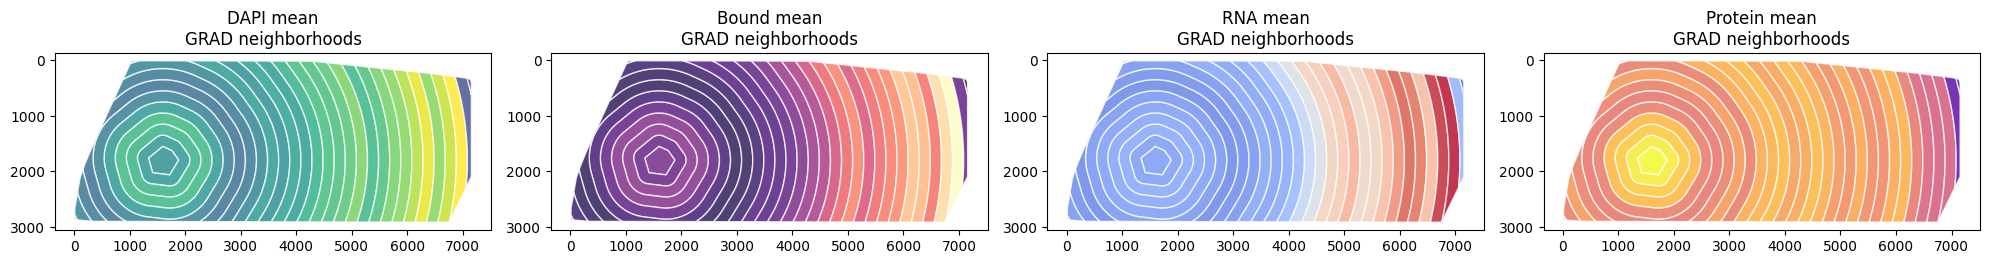

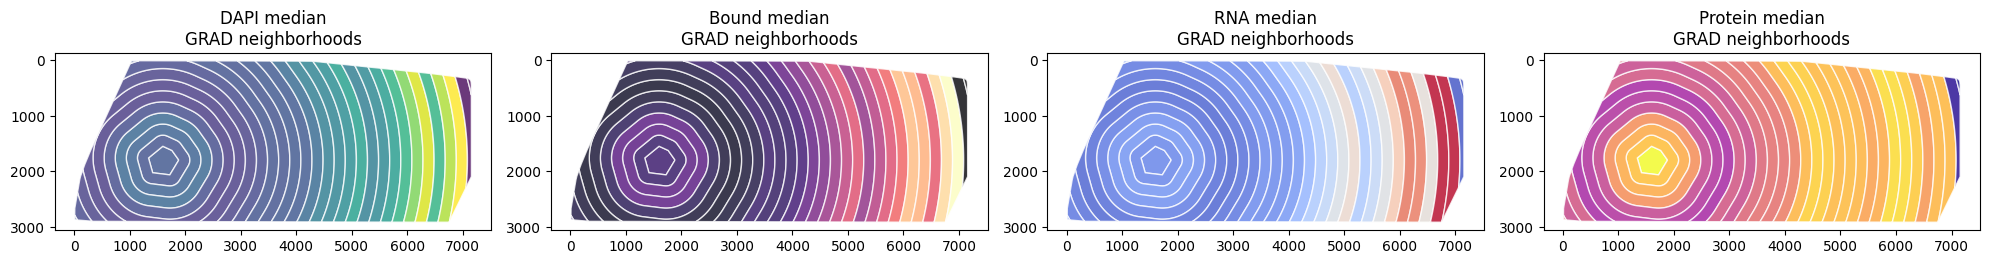

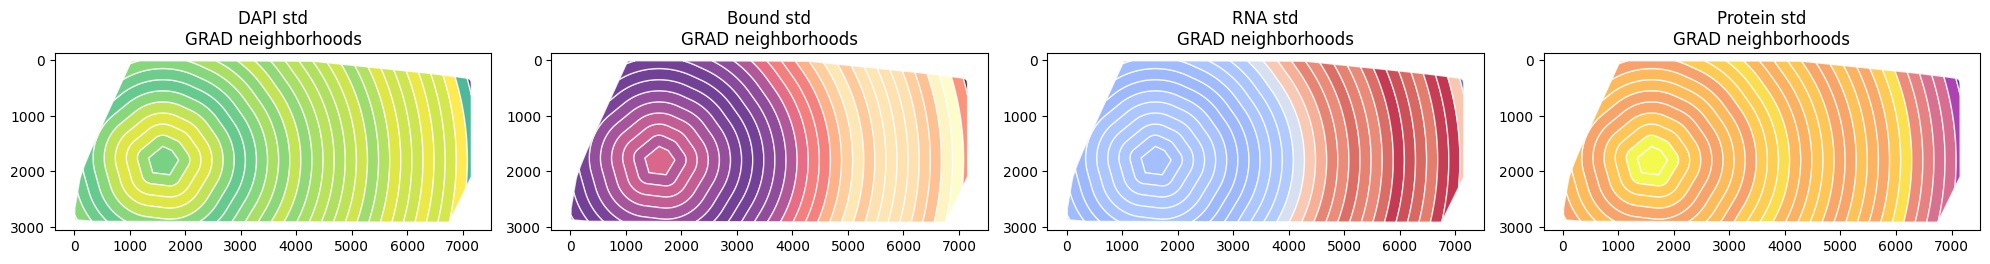

In [6]:
# Retrieve and visualize
metrics = ['mean','median','std']
for metric in metrics:
    gdf_nbi = nbhd.get_derived('NBI', metric)

    if metric == 'mean':
        print (f'NBI data example, metric:{metric}')
        display(gdf_nbi.head(3))       

    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20,7))
    
    # DAPI plot (leftmost)
    gdf_nbi.plot('dapi', ax=ax1, aspect=1, cmap='viridis', edgecolor='white', alpha=0.8)
    ax1.set_title(f'DAPI {metric}\n{nbhd_type} neighborhoods')
    ax1.invert_yaxis()
    
    # Bound plot (second)
    gdf_nbi.plot('bound', ax=ax2, aspect=1, cmap='magma', edgecolor='white', alpha=0.8)
    ax2.set_title(f'Bound {metric}\n{nbhd_type} neighborhoods')
    ax2.invert_yaxis()
    
    # RNA plot (third)
    gdf_nbi.plot('rna', ax=ax3, aspect=1, cmap='coolwarm', edgecolor='white', alpha=0.8)
    ax3.set_title(f'RNA {metric}\n{nbhd_type} neighborhoods')
    ax3.invert_yaxis()
    
    # Protein plot (rightmost)
    gdf_nbi.plot('prot', ax=ax4, aspect=1, cmap='plasma', edgecolor='white', alpha=0.8)
    ax4.set_title(f'Protein {metric}\n{nbhd_type} neighborhoods')
    ax4.invert_yaxis()
    
    plt.tight_layout()
    plt.show()

### NBG

NBG-CD data example


,nbhd_id,geometry,ABCC11,ACE2,ACKR1,ACTA2,ACTG2,ADAM28,ADAMTS1,ADGRE1,...,TRAC,TREM2,TSPAN19,UBE2C,UMOD,UPK3B,VCAN,VSIG4,VWA5A,VWF
0,0,"POLYGON ((1596.222 1549.638, 1761.265 1625.348...",0.007556,0.014917,0.024629,0.037711,0.296541,0.055833,0.022346,0.013372,...,0.027387,0.016133,0.011588,0.109069,0.006512,0.006018,0.236555,0.014624,0.067453,0.032575
1,1,"POLYGON ((1197.513 1619.061, 1184.507 1633.324...",0.002217,0.006267,0.003222,0.171908,0.298437,0.063430,0.015178,0.003141,...,0.039415,0.012849,0.002368,0.174467,0.001822,0.001143,0.663855,0.013992,0.034591,0.036167
2,2,"POLYGON ((1085.044 1451.443, 1077.728 1457.741...",0.000571,0.007689,0.004185,0.211925,0.205506,0.064192,0.050826,0.004415,...,0.057676,0.019532,0.004295,0.054912,0.002140,0.001168,0.702985,0.027107,0.026536,0.073783


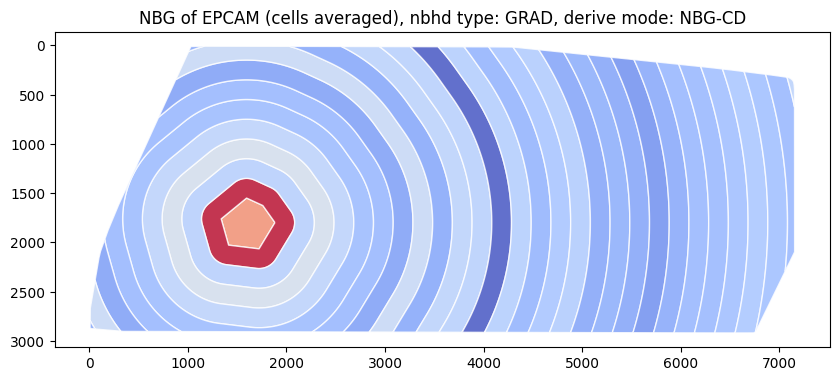

NBG-LCD data example, cluster:1


,nbhd_id,geometry,ABCC11,ACE2,ACKR1,ACTA2,ACTG2,ADAM28,ADAMTS1,ADGRE1,...,TRAC,TREM2,TSPAN19,UBE2C,UMOD,UPK3B,VCAN,VSIG4,VWA5A,VWF
0,0,"POLYGON ((1596.222 1549.638, 1761.265 1625.348...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
1,1,"POLYGON ((1197.513 1619.061, 1184.507 1633.324...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
2,2,"POLYGON ((1085.044 1451.443, 1077.728 1457.741...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.489548,0.0,0.0,0.0,0.0,0.0


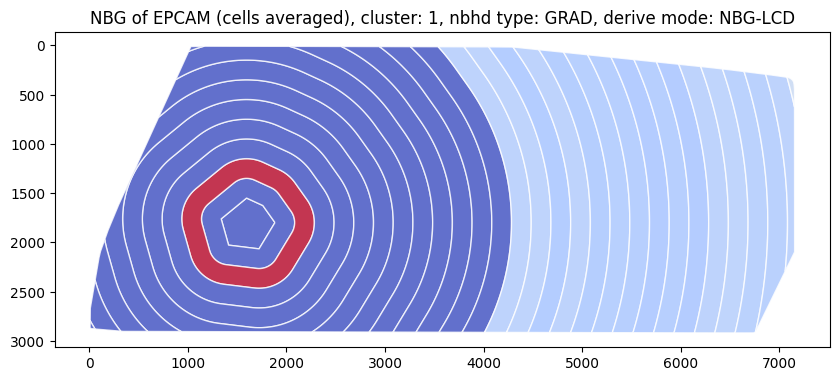

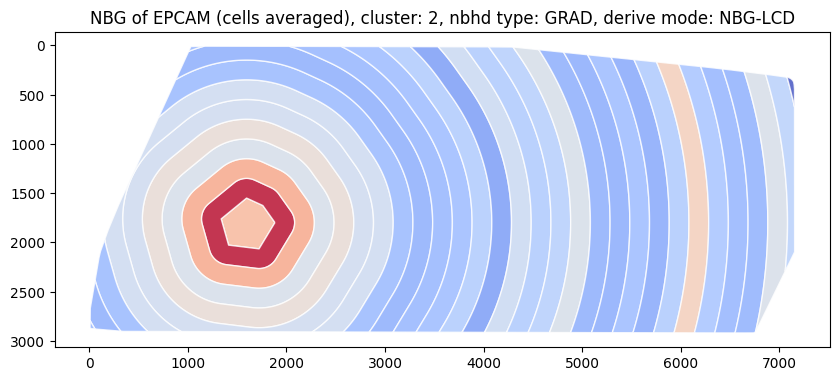

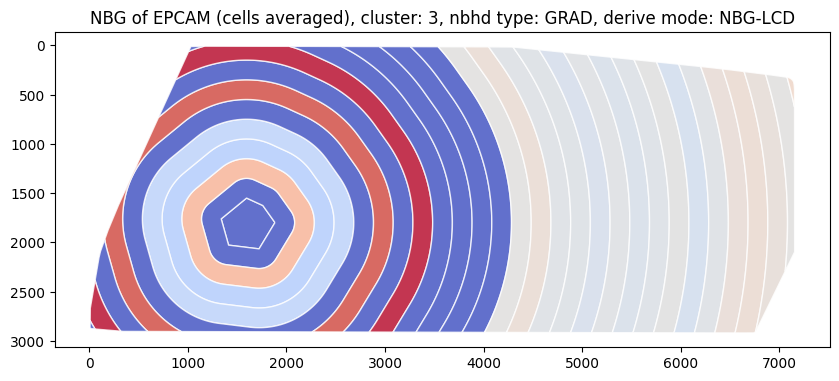

NBG-CF data example


,nbhd_id,geometry,ABCC11,ACE2,ACKR1,ACTA2,ACTG2,ADAM28,ADAMTS1,ADGRE1,...,UnassignedCodeword_0494,UnassignedCodeword_0495,UnassignedCodeword_0496,UnassignedCodeword_0497,UnassignedCodeword_0498,UnassignedCodeword_0499,VCAN,VSIG4,VWA5A,VWF
0,0.0,"POLYGON ((1596.222 1549.638, 1761.265 1625.348...",18,45,60,98,744,121,49,48,...,4,4,0,0,0,1,646,43,131,91
1,1.0,"POLYGON ((1197.513 1619.061, 1184.507 1633.324...",14,59,27,1452,2453,449,92,26,...,6,4,1,1,1,0,7090,89,227,318
2,2.0,"POLYGON ((1085.044 1451.443, 1077.728 1457.741...",6,65,64,2655,2474,530,412,43,...,5,15,1,2,2,2,11150,269,241,788


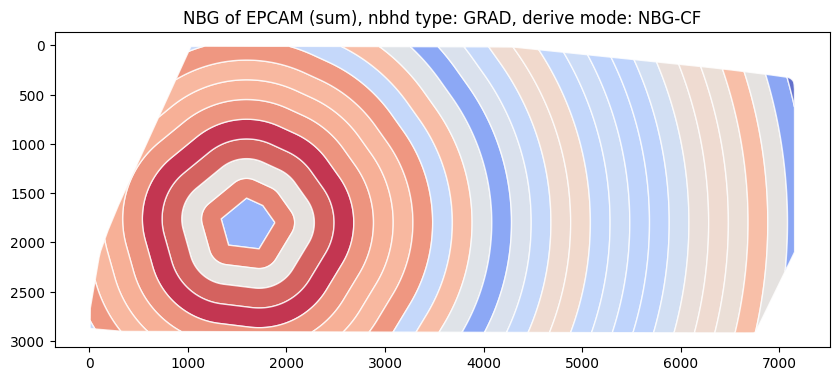

In [7]:
gene = 'EPCAM'

# Retrieve and visualize
gdf_nbg_cd = nbhd.get_derived('NBG-CD')
print ('NBG-CD data example')
display(gdf_nbg_cd.head(3))

fig, ax = plt.subplots(figsize=(10, 5))                           
gdf_nbg_cd.plot(gene, ax=ax, aspect=1, cmap='coolwarm', edgecolor='white', alpha=0.8)
ax.set_title(f'NBG of {gene} (cells averaged), nbhd type: {nbhd_type}, derive mode: NBG-CD')
ax.invert_yaxis()
plt.show()

# Retrieve and visualize
clusters = ['1','2','3']
for cluster in clusters:
    gdf_nbg_lcd = nbhd.get_derived('NBG-LCD', cluster)

    if cluster == '1':
        print (f'NBG-LCD data example, cluster:{cluster}')
        display(gdf_nbg_lcd.head(3))       

    fig, ax = plt.subplots(figsize=(10, 5))                           
    gdf_nbg_lcd.plot(gene, ax=ax, aspect=1, cmap='coolwarm', edgecolor='white', alpha=0.8)
    ax.set_title(f'NBG of {gene} (cells averaged), cluster: {cluster}, nbhd type: {nbhd_type}, derive mode: NBG-LCD')       
    ax.invert_yaxis()
    plt.show()


# Retrieve and visualize
gdf_nbg_cf = nbhd.get_derived('NBG-CF')

print ('NBG-CF data example')
display(gdf_nbg_cf.head(3))

fig, ax = plt.subplots(figsize=(10, 5))                           
gdf_nbg_cf.plot(gene, ax=ax, aspect=1, cmap='coolwarm', edgecolor='white', alpha=0.8)
ax.set_title(f'NBG of {gene} (sum), nbhd type: {nbhd_type}, derive mode: NBG-CF')
ax.invert_yaxis()
plt.show()


### NBP

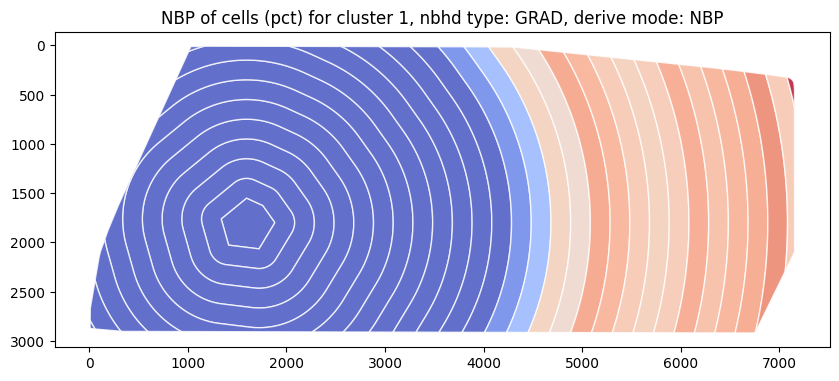

In [8]:
# Retrieve and visualize
sub_key = 'pct'
cluster_name = '1'

gdf_nbp = nbhd.get_derived('NBP', sub_key)

fig, ax = plt.subplots(figsize=(10, 5))                           
gdf_nbp.plot(cluster_name, ax=ax, aspect=1, cmap='coolwarm', edgecolor='white', alpha=0.8)
ax.set_title(f'NBP of cells ({sub_key}) for cluster {cluster_name}, nbhd type: {nbhd_type}, derive mode: NBP')
ax.invert_yaxis()
plt.show()

### NBM (metadata)

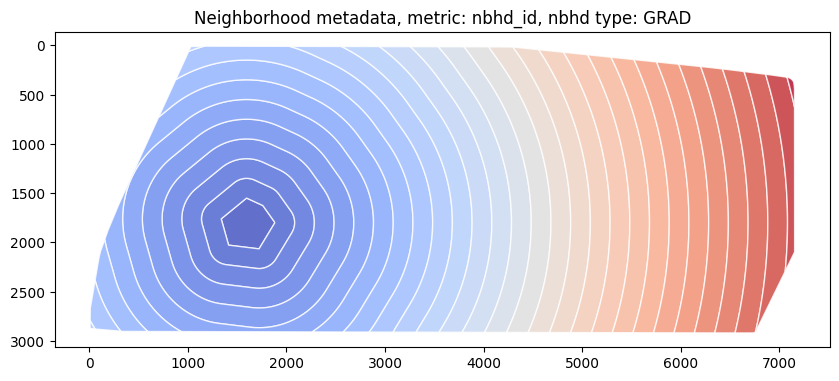

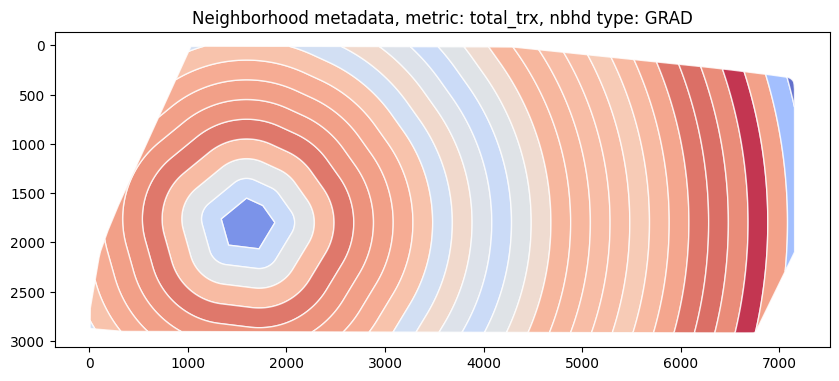

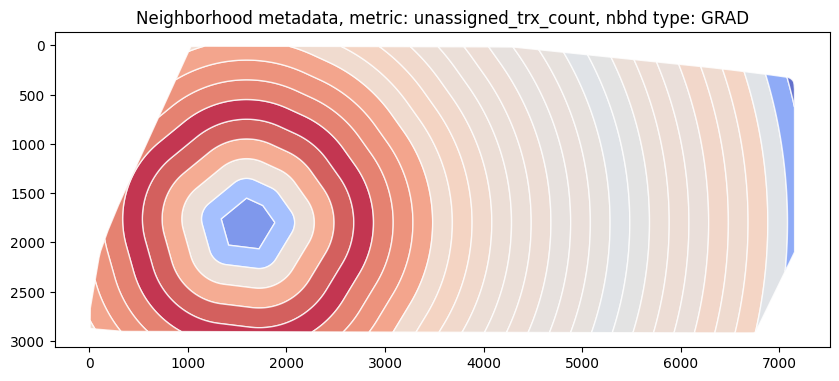

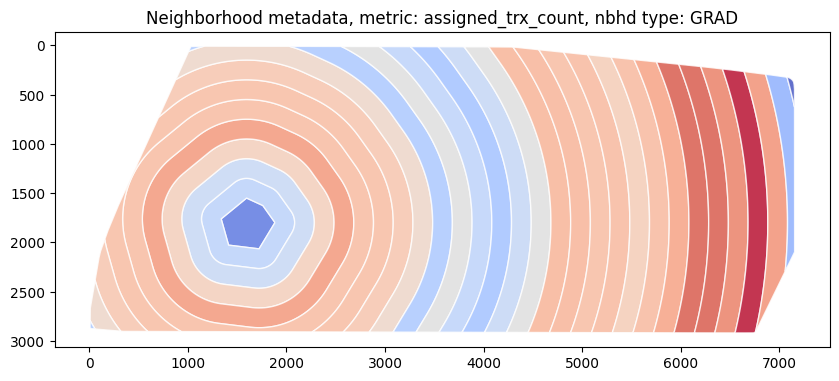

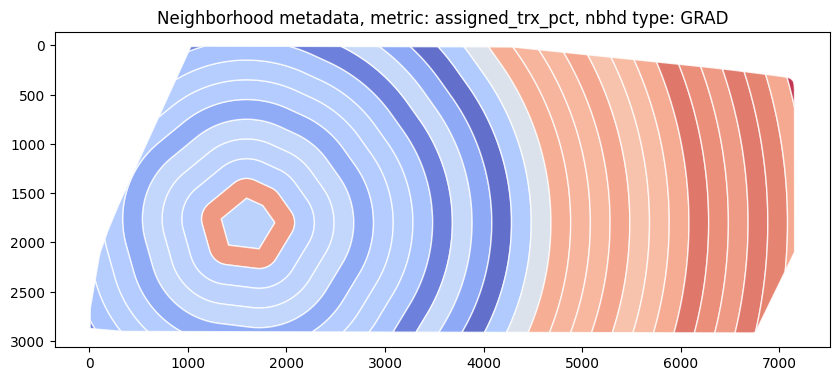

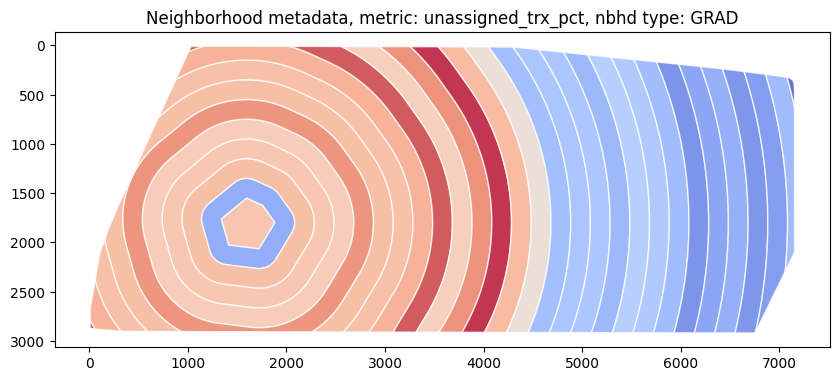

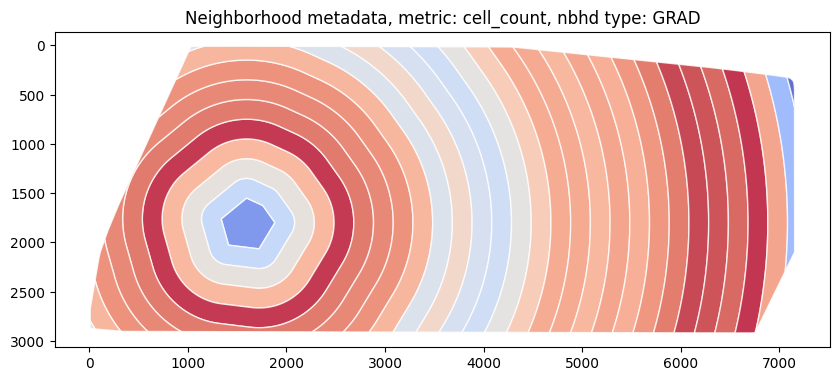

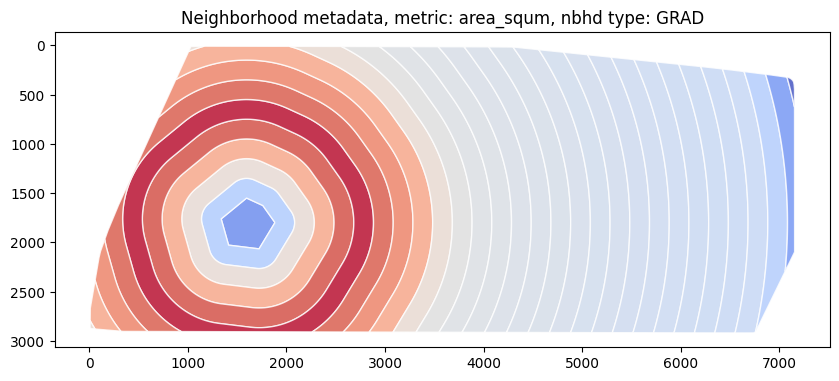

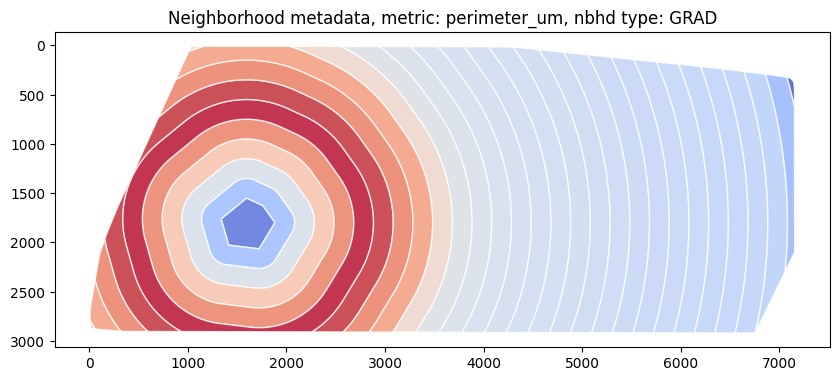

In [9]:
meta = nbhd.get_derived('NBM', df_meta)

for metric in meta.select_dtypes(include='number').columns:
    fig, ax = plt.subplots(figsize=(10, 5))                           
    meta.plot(metric, ax=ax, aspect=1, cmap='coolwarm', edgecolor='white', alpha=0.8)
    ax.set_title(f'Neighborhood metadata, metric: {metric}, nbhd type: {nbhd_type}')
    ax.invert_yaxis()
    plt.show()

In [10]:
nbhd.summary()

{'name': 'X cell alpha shapes',
 'type': 'GRAD',
 'n_regions': 29,
 'derived': {'NBI': {'mean': (29, 4), 'median': (29, 4), 'std': (29, 4)},
  'NBG-CF': (29, 541),
  'NBG-CD': (29, 377),
  'NBG-LCD': {'4': (29, 377),
   '2': (29, 377),
   '0': (29, 377),
   '7': (29, 377),
   '3': (29, 377),
   '9': (29, 377),
   '8': (29, 377),
   '6': (29, 377),
   '5': (29, 377),
   '1': (29, 377),
   '10': (29, 377)},
  'NBP': {'abs': (29, 11), 'pct': (29, 11)},
  'NBN-O': None,
  'NBN-B': None,
  'NBM': (29, 8)},
 'meta': {}}

# Neighborhood by neighborhood

ALPH
calculating neighborhood overlap
(49, 4)


,nbhd_1,nbhd_2,overlap_area,geometry
0,0_35,2_35,4679966.74,"MULTIPOLYGON (((313.206 2859.320, 323.670 2863..."
1,0_35,1_35,34152.73,"MULTIPOLYGON (((6632.260 2752.140, 6628.363 27..."
2,0_35,3_35,86889.75,"MULTIPOLYGON (((6696.800 2740.560, 6691.240 27..."
3,0_35,5_35,297301.74,"MULTIPOLYGON (((6716.072 2741.804, 6702.230 27..."
4,0_35,6_35,27883.91,"MULTIPOLYGON (((6435.489 2778.942, 6458.940 27..."


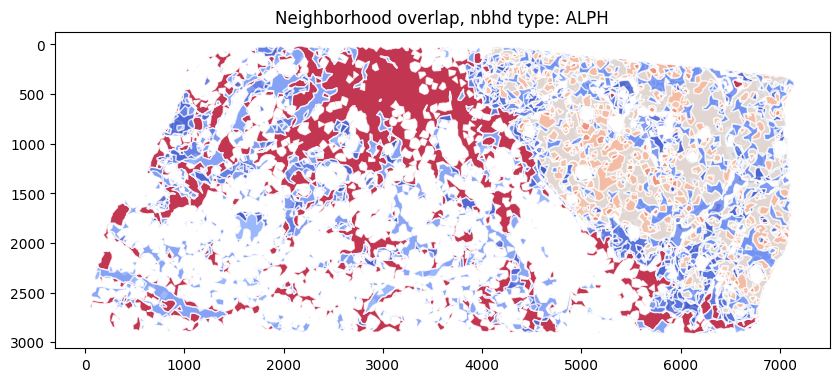

pivoted matrix


,0_35,10_35,1_35,2_35,3_35,4_35,5_35,6_35,7_35,8_35,9_35
0_35,NaN,12425.00,34152.73,4679966.74,86889.75,764157.63,297301.74,27883.91,637836.70,1026608.62,39657.38
10_35,12425.00,0.00,935449.19,31810.22,907615.12,0.00,755690.86,769024.86,58210.66,13642.15,3421.13
1_35,34152.73,935449.19,0.00,95054.43,3843267.53,0.00,2943534.21,3196554.21,283395.54,19837.35,34487.28
2_35,4679966.74,31810.22,95054.43,0.00,163217.27,240085.50,601852.44,107987.58,592361.43,1054802.86,19616.26
3_35,86889.75,907615.12,3843267.53,163217.27,0.00,0.00,2876013.72,2976043.83,448579.30,39194.98,52438.54
4_35,764157.63,0.00,0.00,240085.50,0.00,0.00,0.00,0.00,10221.88,27540.88,0.00
5_35,297301.74,755690.86,2943534.21,601852.44,2876013.72,0.00,0.00,2351732.16,423409.85,138812.96,34036.30
6_35,27883.91,769024.86,3196554.21,107987.58,2976043.83,0.00,2351732.16,0.00,192429.44,24778.17,17595.19
7_35,637836.70,58210.66,283395.54,592361.43,448579.30,10221.88,423409.85,192429.44,0.00,206143.71,12580.99
8_35,1026608.62,13642.15,19837.35,1054802.86,39194.98,27540.88,138812.96,24778.17,206143.71,0.00,14818.21


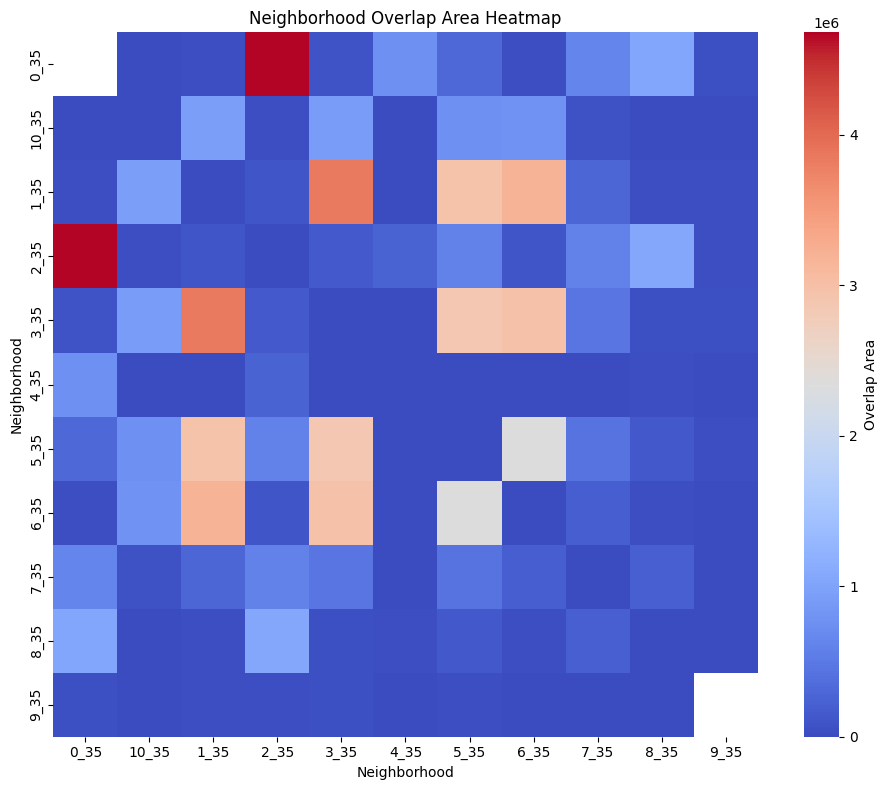

HEX
calculating neighborhood bordering
(5285, 2)


,nbhd_1,nbhd_2
0,hex_0,hex_1
1,hex_0,hex_44
2,hex_1,hex_2
3,hex_3,hex_4
4,hex_4,hex_5


SKTCH
calculating neighborhood bordering
(0, 2)


,nbhd_1,nbhd_2


GRAD
calculating neighborhood bordering
(28, 2)


,nbhd_1,nbhd_2
0,0,1
1,1,2
2,2,3
3,3,4
4,4,5


In [11]:

for nbhd_type in ['ALPH', 'HEX', 'SKTCH', 'GRAD']:
    print (nbhd_type)
    gdf_nbhd = nbhd_lookup[nbhd_type]
    nb = gdf_nbhd[['name','geometry']]


    if nbhd_type == 'ALPH':
        print ('calculating neighborhood overlap')
        df_nn = dega.nbhd.calc_nb_overlap(nb)
        print (df_nn.shape)
        display(df_nn.head(5))

        if len(df_nn) > 0:
            fig, ax = plt.subplots(figsize=(10, 5))                           
            df_nn.plot('overlap_area', ax=ax, aspect=1, cmap='coolwarm', edgecolor='white', alpha=0.8)
            ax.set_title(f'Neighborhood overlap, nbhd type: {nbhd_type}')
            ax.invert_yaxis()
            plt.show()

            # Step 1: Pivot the data into a matrix
            df_matrix = df_nn.pivot(index="nbhd_1", columns="nbhd_2", values="overlap_area")

            # Step 2: Fill NaNs with 0 (no overlap) and make symmetric (optional but cleaner)
            df_matrix = df_matrix.fillna(0)
            df_matrix = df_matrix.add(df_matrix.T, fill_value=0)  # Symmetrize

            print ('pivoted matrix')
            display(df_matrix)

            # Step 3: Plot heatmap
            plt.figure(figsize=(10, 8))
            sns.heatmap(df_matrix, cmap="coolwarm", annot=False, square=True, cbar_kws={'label': 'Overlap Area'})
            plt.title("Neighborhood Overlap Area Heatmap")
            plt.xlabel("Neighborhood")
            plt.ylabel("Neighborhood")
            plt.tight_layout()
            plt.show()
    else:
        print ('calculating neighborhood bordering')
        df_nn = dega.nbhd.calc_nb_bordering(nb)
        print (df_nn.shape)
        display(df_nn.head(5))


# Mudata testing

In [19]:
# # Testing
# munbhd = MuData({
#     "nbg": AnnData(X=nbg_mat, obs=gdf, var=genes...),   # gene expression
#     "nbp": AnnData(X=nbp_mat, obs=gdf, var=pop ...),    # population proportions
#     "nbi": AnnData(X=nbi_mat, obs=gdf, var=images ...), # image intensities
#     "nbn": AnnData(X=nbn_mat, obs=gdf, var=gdf ...),    # spatial interaction matrix
# })


# mdata.write(f"{path_landscape_files}/nhbd_collections.h5mu")  

# import muon as mu

# # Load the h5mu file
# mdata = mu.read(f"{path_landscape_files}/nhbd_collections.h5mu")

In [ ]:


# Define the path to the morphology image
file_path = f"{data_dir}/morphology_focus/morphology_focus_0000.ome.tif"

# Load the morphology image
img = imread(file_path)

# Convert gdf_nbhd to pixel space
path_transformation_matrix = f'{path_landscape_files}/micron_to_image_transform.csv'

transformation_matrix = pd.read_csv(
    path_transformation_matrix, header=None, sep=" "
).values

gdf_nbhd_pixel = gdf_nbhd.copy()
gdf_nbhd_pixel["geometry"] = batch_transform_geometries(gdf_nbhd_pixel["geometry"], transformation_matrix, 1)

# Extract zonal stats
nbi_dict = {}
channel_name_dict = {0:'dapi',1:'bound', 2:'rna', 3:'prot'}
for metric in ['mean', 'median', 'std']:
    nbi_dict[metric] = dega.nbhd.calc_img_zonal_stats(gdf_nbhd_pixel, img, channel_names=channel_name_dict, stats_func =metric)


<tifffile.TiffFile 'morphology_focus_0000.ome.tif'> OME series cannot read multi-file pyramids


In [ ]:

gdf_nbhd_pixel = gdf_nbhd.copy()

path_transformation_matrix = f'{path_landscape_files}/micron_to_image_transform.csv'

transformation_matrix = pd.read_csv(
    path_transformation_matrix, header=None, sep=" "
).values

gdf_nbhd_pixel = gdf_nbhd.copy()
gdf_nbhd_pixel["geometry"] = batch_transform_geometries(gdf_nbhd_pixel["geometry"], transformation_matrix, 1)

nbi_dict = {}
channel_name_dict = {0:'dapi',1:'bound', 2:'rna', 3:'prot'}
for metric in ['mean', 'median', 'std']:
    nbi_dict[metric] = dega.nbhd.calc_img_zonal_stats(gdf_nbhd_pixel, img, channel_names=channel_name_dict, stats_func =metric)

In [151]:
nbi_dict = {}
channel_name_dict = {0:'dapi',1:'bound', 2:'rna', 3:'prot'}
for metric in ['mean', 'median', 'std']:
    nbi_dict[metric] = dega.nbhd.calc_img_zonal_stats(gdf_nbhd_pixel, img, channel_names=channel_name_dict, stats_func =metric)


In [152]:
nbi_dict['mean']

,polygon_id,dapi,bound,rna,prot
0,0_35,319.331826,520.456716,658.541872,270.427745
1,2_35,331.203246,569.845485,741.842489,276.421828
2,1_35,478.294969,1153.459834,1702.384228,273.384446
3,3_35,476.892087,1152.033233,1711.228723,273.437866
4,5_35,478.319737,1125.310973,1709.852483,269.805330
5,6_35,488.122699,1177.148931,1753.694186,267.497039
6,4_35,290.712113,450.316063,568.373751,290.381735
7,8_35,330.600430,636.748772,867.446123,241.000158
8,7_35,406.969653,809.665248,1136.291611,267.527188
9,10_35,480.096568,1152.334806,1673.069919,284.300582


In [153]:
nbi_dict['median']

,polygon_id,dapi,bound,rna,prot
0,0_35,74.0,218.0,230.0,80.0
1,2_35,79.0,258.0,271.0,82.0
2,1_35,179.0,744.0,945.0,117.0
3,3_35,177.0,741.0,943.0,117.0
4,5_35,179.0,724.0,932.0,116.0
5,6_35,188.0,773.0,998.0,116.0
6,4_35,70.0,173.0,189.0,93.0
7,8_35,79.0,269.0,284.0,79.0
8,7_35,118.0,448.0,455.0,102.0
9,10_35,181.0,743.0,929.0,118.0


In [154]:
nbi_dict['std']

,polygon_id,dapi,bound,rna,prot
0,0_35,548.240151,813.908046,1128.548949,630.029807
1,2_35,546.636604,852.061683,1242.700440,646.202784
2,1_35,594.121477,1331.831899,1937.992001,598.609744
3,3_35,593.696158,1336.549432,1953.429896,595.616664
4,5_35,594.493546,1304.829117,1960.871186,590.242816
5,6_35,597.177108,1336.143997,1958.269344,588.865383
6,4_35,518.648108,756.202494,1019.676696,653.026498
7,8_35,544.567724,969.307574,1436.009634,566.772672
8,7_35,583.042986,1071.134155,1672.434207,567.810106
9,10_35,594.798067,1336.478903,1922.334044,625.336097
